# Lab 03: Is There a Planet in Your Light Curve?

**ASTR 457, Fall 2026, posted Thu Sep 17, due Wed Sep 23 by Noon (fork → PR, as always)**

*Why this lab: transit fitting by maximum likelihood is how thousands of planets, including every temperate world around an M dwarf that David Charbonneau will talk about at the Sep 29 colloquium, were actually measured, and the gap between an error bar computed the lazy way and one computed honestly is exactly the gap between a claim that survives referees and one that doesn't.*

Every one of you has your own dataset: `data/<your netid>.csv`, with columns `t_days`
(time from the start of a ~27-day TESS-style observing sector, 30-minute cadence, with a
~1-day data gap in the middle), `flux_rel` (relative flux, normalized near 1), and
`sigma_flux` (the per-point **white-noise** uncertainty). Your star is a nearby M dwarf
with a candidate transiting super-Earth. The light curve contains: the transit train,
slow instrumental systematics (drifts over days), and, as you will discover, noise
that is not entirely captured by `sigma_flux`. I know the true mid-transit time $t_0$,
period $P$, depth $\delta$, and duration $T$ for your dataset. You don't, you can't look
them up, and your classmates' planets are different from yours.

**How this is graded.** As always: on whether your answers are *right* and your
uncertainties are *honest*. Your reported depth and period are compared to your truth in
units of your own reported uncertainty. Anti-sandbagging cap: your $\sigma_\delta$ may
not exceed 3× a reference uncertainty I compute for your dataset; defensive error bars
lose points just like overconfident ones.

**AI policy reminder.** Use whatever tools you like, including AI assistants, and
document it in Part 4. You may be selected to defend this lab in person (the practice
round was Sep 15; the real ones use the same format).

## The transit model (given)

Use this five-parameter periodic trapezoid, the small-planet limit of Mandel & Agol
(2002), the same model from Tuesday's lecture. The parameters are
$\theta = (t_0, P, \delta, T, F_0)$: mid-transit time of the first transit, period,
depth, total duration, and out-of-transit baseline flux. Ingress and egress each span
20% of the duration.

In [70]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.interpolate import interp1d

def transit_model(t, t0, period, depth, duration, baseline, ingress_frac=0.2):
    """Periodic trapezoidal transit train."""
    ph = ((t - t0 + 0.5 * period) % period) - 0.5 * period
    half = duration / 2.
    ing = ingress_frac * duration
    f = np.ones_like(t)
    inside = np.abs(ph) < half
    full = np.abs(ph) < (half - ing)
    f[inside] = 1. - depth * np.clip((half - np.abs(ph[inside])) / ing, 0., 1.)
    f[full] = 1. - depth
    return baseline * f

NETID = 'asteves2'  # <-- set this
d = np.genfromtxt(f'/Users/andrewsteves/ast457_2026_Fall/labs/03/data/{NETID}.csv', delimiter=',', names=True, skip_header=1)
t, flux, sigma = d['t_days'], d['flux_rel'], d['sigma_flux']
print(f'{len(t)} points spanning {t[-1]:.1f} days; stated sigma = {sigma[0]*1e3:.2f} ppt')

1263 points spanning 27.4 days; stated sigma = 1.37 ppt


## Part 1: Find the planet (20%)

1. Plot the raw light curve. Identify the slow systematic trend and the transits.
2. **Detrend** the light curve. Be deliberate: state your method (median filter, spline,
   polynomial per segment, your choice), your smoothing scale, and *why that scale
   can't eat your transits*. Plot raw, trend, and detrended flux.
3. From the detrended curve, read off by eye: approximate $t_0$, $P$, depth, duration:
   your initial guesses for Part 2.
4. Compare the out-of-transit scatter of your detrended flux to the stated `sigma_flux`.
   Are they consistent? Say what you conclude (a sentence is fine, and you'll need this
   observation in Parts 2 and 3).

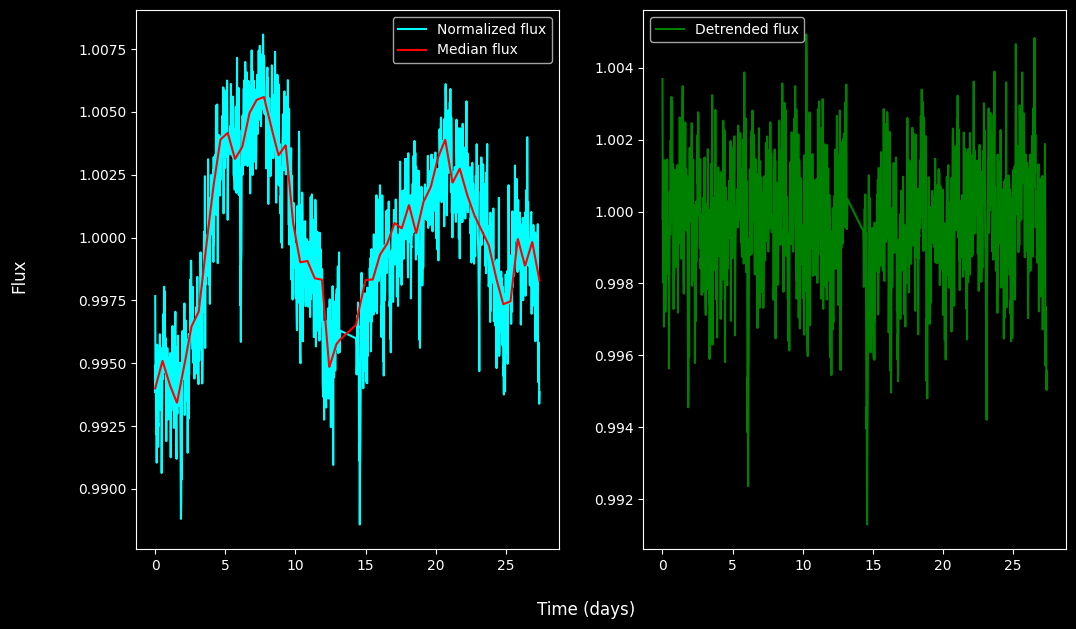

Scatter variance: 2.852e-06
Given variance: 1.370e-03


In [71]:
# Part 1: your work here

segments = np.array_split(t, 54)        #Array split into 36 segments because light curve shows slightly less than two full periods with two segments per day
t_med_flux = np.linspace(0, t[-1], 54)

med_filter = []
for i in range(len(segments)):
    left = segments[i][0]
    right = segments[i][-1]
    mask = (t >= left) & (t <= right)
    med = np.median(flux[mask])
    med_filter.append(med)

interp = interp1d(t_med_flux, med_filter, kind='linear')
trend = interp(t)

detrended = flux / trend

mask = (t <= 13)
ots = detrended[mask]               #Regions of out-of-transit scatter
var = np.var(ots)
var_flux = np.mean(sigma)

fig, ax = plt.subplots(ncols = 2, nrows = 1, figsize = (12, 7))
ax[0].plot(t, flux, label = 'Normalized flux', color = 'cyan')
ax[0].plot(t, trend, label = 'Median flux', color = 'red')
ax[1].plot(t, detrended, label = 'Detrended flux', color = 'green')

fig.supxlabel('Time (days)')
fig.supylabel('Flux')

ax[0].legend()
ax[1].legend()
plt.show()

print(f'Scatter variance: {var:.3e}')
print(f'Given variance: {var_flux:.3e}')

**ANSWERS (initial guesses + scatter check):**

The general shape of the light curve is very clear, being sinusoidal in nature with a lot of background noise and a period of roughly 10 days. A median filter is used to create a trend for the flux because it only draws on data points already in the set, potentially limiting any issues with interpolation. Here, the smoothing timescale is chosen to be 1/54, allowing for each window to account for half of one day throughout the duration of observation. After detrending, it appears that t0=7 is a safe initial time as well as the transit having a period of around 14 days, which is significantly longer than the initial estimate (at least on the time scales of transits). It seems that the scatter of the detrended flux is 3 orders of magnitude smaller than the reported variance values.

## Part 2: The measurement you'd publish (40%)

1. Write the Gaussian log-likelihood for the transit model and maximize it
   (`scipy.optimize.minimize`; Nelder-Mead first, as in lecture). Fit all five
   parameters. Plot the phase-folded data with your best-fit model, and the residuals.
2. Estimate uncertainties **two ways**:
   - from the curvature of the log-likelihood at the maximum (the inverse Hessian,
     lecture method), and
   - by **bootstrap**, and think about *what* you resample: if you resample individual
     points, what are you assuming about the noise? A block bootstrap (resample
     contiguous chunks of residuals, e.g. 1-day blocks) makes a different assumption.
     Do both point-wise and block versions and compare.
3. The three uncertainty estimates for the depth will not all agree. Explain the pattern
   using your Part 1 scatter observation. Which noise property do the Hessian and the
   point-wise bootstrap both assume that your residuals violate? Demonstrate that
   violation with a plot or a number (hint: bin your residuals in ~5-hour bins and
   compare the binned scatter to what independent noise predicts).
4. **Commit to final answers**: $\delta \pm \sigma_\delta$, $P \pm \sigma_P$,
   $t_0 \pm \sigma_{t_0}$, and justify which uncertainty estimate you adopted.

0.04055771646283176 0.1547317350089673 1.8076620387006813e-05


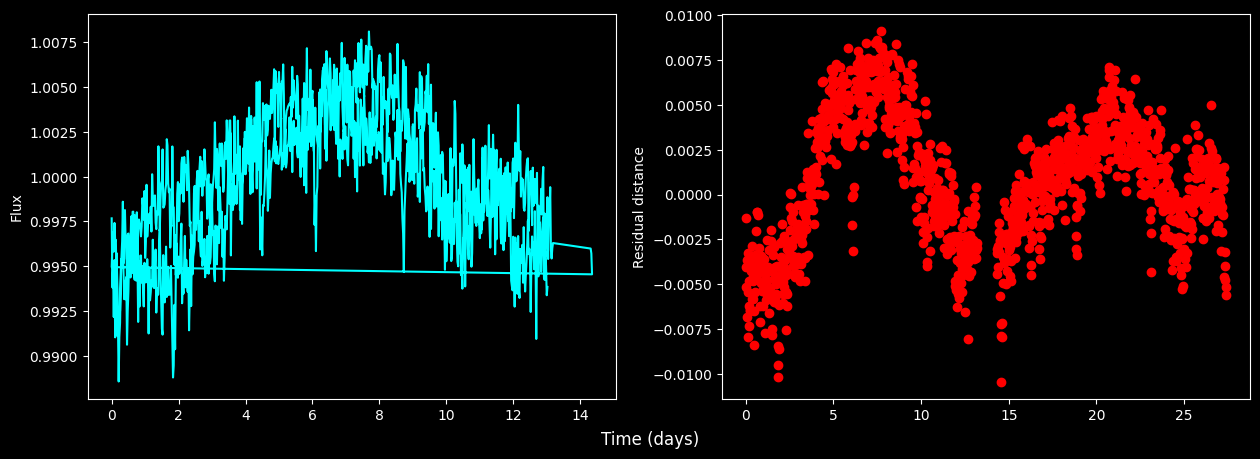

In [89]:
# Part 2: your work here
theta = [7, 14, 0.001, 27, 1]

def gauss_log_likelihood(theta, y, sig):
    mu = transit_model(t, *theta)
    fun = np.sum(-1/2 * np.log(2 * np.pi * sig**2) - ((y - mu)**2) / (2 * sig**2))
    return -fun

outputs = minimize(gauss_log_likelihood, x0 = theta, args = (flux, sigma))
t0, P, delta, T, F0 = outputs.x[0], outputs.x[1], outputs.x[2], outputs.x[3], outputs.x[4]

cov = outputs.hess_inv
sig_t0, sig_P, sig_delta = np.sqrt(cov[0, 0]), np.sqrt(cov[1, 1]), np.sqrt(cov[2, 2])

t0_point_boot = []
P_point_boot = []
delta_point_boot = []

for i in range(1000):
    rng = np.random.default_rng(i)
    indices = np.array([rng.integers(0, len(t) - 1, endpoint = True) for _ in range(len(t))])
    boot_flux, boot_sig = flux[indices], sigma[indices]

    res = minimize(gauss_log_likelihood, x0 = theta, args = (boot_flux, boot_sig), method = 'Nelder-Mead')
    t0, P, delta = res.x[0], res.x[1], res.x[2]
    t0_point_boot.append(t0)
    P_point_boot.append(P)
    delta_point_boot.append(delta)

std_t0_point = np.std(t0_point_boot)
std_P_point_boot = np.std(P_point_boot)
std_delta_point_boot = np.std(delta_point_boot)









mu = transit_model(t, *theta)
res = flux - mu

fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (15, 5))
ax[0].plot(t % P, flux, label = 'Phase-folded flux', color = 'cyan')
ax[0].set_ylabel('Flux')

ax[1].scatter(t, res, label = 'Residuals', color = 'red')
ax[1].set_ylabel('Residual distance')

fig.supxlabel('Time (days)')

plt.show()

**FINAL ANSWER:** $\delta = $ 0.00097 $\pm$ ___ ppt, $P = $ 14.108 $\pm$ ___ d, $t_0 = $ 7.199 $\pm$ ___ d

**Which uncertainty and why (a short paragraph):**

*your answer goes here*

## Part 3: The referee report (30%)

The file `ai_solution.ipynb` in this directory is a complete, tidy, confident analysis
of this exact problem, produced by an AI assistant. It runs top to bottom without
errors, the phase-folded plot looks professional, and the prose is fluent. It is also
wrong, in at least **three** distinct, substantive ways (cosmetic nitpicks don't
count).

Write a referee report:

1. **Identify** at least three substantive statistical errors.
2. **Demonstrate** each one quantitatively on *your* dataset. Show, with a number or a
   plot, what the error does to the inference. "This is bad practice" is not a
   demonstration.
3. **State** what the correct treatment is (you already built it in Part 2).

You've done this once before, on Lab 01. Notice how much faster you are at it now.
That speed is the skill this course is building.

**REFEREE REPORT:**

*Flaw 1:*

*Flaw 2:*

*Flaw 3:*

In [73]:
# Part 3: demonstrations here


## Part 4: AI-use appendix & verification plan (10%)

1. **AI use**: which tools did you use, for what, what did they get wrong, and how did
   you catch it? Honesty is graded; "I didn't use any" is fine if true.
2. **Verification plan**: list the checks you ran before deciding to trust your Part 2
   numbers. For each check: what would failure have looked like? (One check you should
   seriously consider: simulate a light curve with parameters you chose, run your whole
   pipeline on it, and see whether you recover what you put in.)

**AI-USE APPENDIX:**

*your answer goes here*

**VERIFICATION PLAN:**

*your answer goes here*